#### MACHINE LEARNING - SUPERVISED

Linear Regression

In [2]:
#import libs
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [67]:
#load the dataset
hr=pd.read_csv(r"C:\Users\indug\Downloads\framingham.csv\Lab 21 House_Rent_Dataset.csv")
#show top 5
hr.head(5)

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [68]:
#how many rows and cols
hr.shape

(4746, 12)

In [69]:
hr.info()

<class 'pandas.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Posted On          4746 non-null   str  
 1   BHK                4746 non-null   int64
 2   Rent               4746 non-null   int64
 3   Size               4746 non-null   int64
 4   Floor              4746 non-null   str  
 5   Area Type          4746 non-null   str  
 6   Area Locality      4746 non-null   str  
 7   City               4746 non-null   str  
 8   Furnishing Status  4746 non-null   str  
 9   Tenant Preferred   4746 non-null   str  
 10  Bathroom           4746 non-null   int64
 11  Point of Contact   4746 non-null   str  
dtypes: int64(4), str(8)
memory usage: 445.1 KB


In [70]:
hr['Posted On'].dtype

<StringDtype(storage='python', na_value=nan)>

In [71]:
hr['Rent'].dtype

dtype('int64')

In [72]:
#stats of data
hr.describe()

,BHK,Rent,Size,Bathroom
count,4746.000000,4.746000e+03,4746.000000,4746.000000
mean,2.083860,3.499345e+04,967.490729,1.965866
std,0.832256,7.810641e+04,634.202328,0.884532
min,1.000000,1.200000e+03,10.000000,1.000000
25%,2.000000,1.000000e+04,550.000000,1.000000
50%,2.000000,1.600000e+04,850.000000,2.000000
75%,3.000000,3.300000e+04,1200.000000,2.000000
max,6.000000,3.500000e+06,8000.000000,10.000000


In [73]:
hr.isnull().sum()

Posted On            0
BHK                  0
Rent                 0
Size                 0
Floor                0
Area Type            0
Area Locality        0
City                 0
Furnishing Status    0
Tenant Preferred     0
Bathroom             0
Point of Contact     0
dtype: int64

In [74]:
#missing value treatment
#1.dropna method - drops row
#2.fillna method - fill rows with mean ,median ormode
#3.axis =1 -> remove columns axis=0->remove rows

In [75]:
#list of columns
hr.columns

Index(['Posted On', 'BHK', 'Rent', 'Size', 'Floor', 'Area Type',
       'Area Locality', 'City', 'Furnishing Status', 'Tenant Preferred',
       'Bathroom', 'Point of Contact'],
      dtype='str')

In [76]:
hr=hr.drop(['Posted On'],axis=1) 
hr.columns

Index(['BHK', 'Rent', 'Size', 'Floor', 'Area Type', 'Area Locality', 'City',
       'Furnishing Status', 'Tenant Preferred', 'Bathroom',
       'Point of Contact'],
      dtype='str')

In [77]:
!pip install xgboost
!pip install category-encoders


[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [78]:
#importing ml libs
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
import sklearn.metrics as mt
import xgboost as xgb
import category_encoders as ce
from sklearn.preprocessing import MinMaxScaler


In [79]:
hr.columns

Index(['BHK', 'Rent', 'Size', 'Floor', 'Area Type', 'Area Locality', 'City',
       'Furnishing Status', 'Tenant Preferred', 'Bathroom',
       'Point of Contact'],
      dtype='str')

In [80]:
hr=hr.drop(['Floor','Area Locality'],axis=1)
hr.columns

Index(['BHK', 'Rent', 'Size', 'Area Type', 'City', 'Furnishing Status',
       'Tenant Preferred', 'Bathroom', 'Point of Contact'],
      dtype='str')

In [81]:
#data splitting - 100%-80% training set and 20% testing set
X = hr.drop(columns='Rent')
y=hr['Rent']

In [82]:
X.head()

,BHK,Size,Area Type,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2,1100,Super Area,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2,800,Super Area,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2,1000,Super Area,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2,800,Super Area,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2,850,Carpet Area,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [83]:
#Encoding - LOO encoder
encoder = ce.LeaveOneOutEncoder(return_df=True)

In [84]:
X=encoder.fit_transform(X,y)

In [85]:
X.head()

,BHK,Size,Area Type,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2,1100,18676.943967,11648.319312,22468.505513,31216.953238,2,16706.291757
1,2,800,18672.853988,11629.198853,38727.130222,31214.048795,1,16703.181337
2,2,1000,18674.080982,11634.934990,38728.463556,31214.920128,1,16704.114463
3,2,800,18676.943967,11648.319312,22468.505513,31216.953238,1,16706.291757
4,2,850,52405.438398,11653.099426,22469.883682,42185.583836,1,16707.069362


In [88]:
#Standardization - scaling 
scaler = MinMaxScaler()
X= scaler.fit_transform(X)
#y=scaler.transform(y)

In [89]:
X

array([[0.2       , 0.13642053, 0.27316184, ..., 0.01795978, 0.11111111,
        0.00321938],
       [0.2       , 0.09887359, 0.27307371, ..., 0.01780886, 0.        ,
        0.00316481],
       [0.2       , 0.12390488, 0.27310014, ..., 0.01785413, 0.        ,
        0.00318118],
       ...,
       [0.4       , 0.21777222, 0.99968293, ..., 0.01758247, 0.22222222,
        0.99965557],
       [0.4       , 0.1864831 , 0.99958912, ..., 0.99558704, 0.11111111,
        0.99954076],
       [0.2       , 0.12390488, 0.99987054, ..., 0.58744851, 0.11111111,
        0.00319209]], shape=(4746, 8))

In [90]:
X_df=pd.DataFrame(X)
X_df.head()

,0,1,2,3,4,5,6,7
0,0.2,0.136421,0.273162,0.004388,0.009553,0.017960,0.111111,0.003219
1,0.2,0.098874,0.273074,0.004130,0.487075,0.017809,0.000000,0.003165
2,0.2,0.123905,0.273100,0.004207,0.487114,0.017854,0.000000,0.003181
3,0.2,0.098874,0.273162,0.004388,0.009553,0.017960,0.000000,0.003219
4,0.2,0.105131,0.999941,0.004452,0.009593,0.587919,0.000000,0.003233


In [93]:
X_train.shape,X_test.shape

((3796, 8), (950, 8))

In [94]:
#train
lr = LinearRegression()

In [95]:
model = lr.fit(X_train,y_train)

In [97]:
model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[ 27628.24,276011.57, 8437.05,...,-10690.88, 82123.72, 11929.03]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-4.097e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(8)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](8,)","[36.15,21.12,19.56,...,11.19, 3.55, 2.52]"


In [99]:
#prediction
y_pred = model.predict(X_test)
y_pred

array([ 2.47948399e+04,  1.64745090e+04,  6.29900183e+04,  6.31263577e+04,
        1.00790970e+05,  3.97633715e+04,  7.49611434e+04,  1.33035079e+04,
        1.74718740e+05,  8.80125705e+03, -3.18756505e+02,  5.23636156e+03,
        3.55871285e+04,  1.14861384e+04,  2.54450768e+04,  4.33307342e+04,
        1.23354848e+05,  1.66611396e+03,  1.58450520e+04,  7.62441931e+04,
        5.11238384e+04, -1.15411571e+04,  6.03710075e+04,  2.78437744e+04,
        1.46424244e+05, -1.42828102e+04, -8.25251318e+03,  5.64952841e+04,
       -1.83937435e+04,  9.93623391e+02, -1.40260219e+04, -8.72491271e+03,
       -7.90951862e+02,  2.18447554e+04,  4.01832617e+04,  4.97706511e+04,
       -4.73821388e+03, -1.42168698e+04,  2.36595909e+04, -5.68739081e+03,
        2.08938140e+04,  1.88398235e+05,  1.81995094e+04, -1.05725484e+04,
        8.05411857e+04,  1.31091113e+04,  7.59802244e+04,  1.00508247e+05,
        1.98732581e+05,  3.30586758e+04,  1.43439235e+04,  6.27822290e+04,
        2.23404027e+04,  

In [100]:
#Evaluate th model
mse = mt.mean_squared_error(y_test, y_pred)
mae= mt.median_absolute_error(y_test,y_pred)
r2=mt.r2_score(y_test,y_pred)
print(f'The mean squared error id {mse}')
print(f'The mean squared error id {mae}')
print(f'The R squared error id {r2}')

The mean squared error id 1931480573.9931836
The mean squared error id 16491.89699428359
The R squared error id 0.5153586519637793


In [101]:
#decision tree
dtr = DecisionTreeRegressor()
model_dtr= dtr.fit(X_train,y_train)
dtr_pred = model_dtr.predict(X_test)
dtr_pred

array([ 16000.,  12000.,  28000.,   8000.,  46000.,  17000.,  56000.,
         9500., 400000.,  15000.,  10000.,  12000.,  27000.,  16000.,
        15000.,   8000., 140000.,  12000.,   6000.,  60000.,  38000.,
         7500.,  23000.,  14000., 260000.,   5000.,   6000.,  16500.,
         6500.,  15000.,   5000.,  14000.,   5000.,  12000.,  25000.,
        25000.,   7500.,   6000.,  17000.,   7000.,  13000., 330000.,
        14000.,   6000.,  60000.,  14000.,  32000.,  65000., 350000.,
        15000.,  11000.,  35000.,  18000.,  12000.,  65000., 130000.,
        35000.,  40000.,   9000.,   9000.,  18000.,   5000., 130000.,
        12000.,  50000.,  20000.,  18000.,  15500.,  35000.,  30000.,
        13000.,  24000., 110000.,   7000.,  25000.,  35000.,  12000.,
        52000.,  35000.,  28000.,  14000.,  10000.,  34000.,  10000.,
        12000.,  45000.,  36000.,  18000.,  25000.,  27000., 250000.,
        35000.,  24000., 120000.,  13000.,  12000.,  11000.,   7000.,
        20000.,  240

In [104]:
mse_dtr = mt.mean_squared_error(y_test,dtr_pred)
mae_dtr = mt.mean_absolute_error(y_test,dtr_pred)
r2_dtr=mt.r2_score(y_test,y_pred)
print(f'The mean squared error is{mse_dtr}')
print(f'The mean squared error is{mae_dtr}')
print(f'The r2 squared error is{r2_dtr}')

The mean squared error is258259634.8105263
The mean squared error is1191.3157894736842
The r2 squared error is0.5153586519637793


In [106]:
rfr= RandomForestRegressor(n_estimators=100)
model_rfr= rfr.fit(X_train,y_train)
rfr_pred= model_rfr.predict(X_test)

In [108]:
mse_rfr = mt.mean_squared_error(y_test,rfr_pred)
mae_rfr = mt.mean_absolute_error(y_test,rfr_pred)
r2_rfr=mt.r2_score(y_test,rfr_pred)
print(f'The mean squared error is{mse_rfr}')
print(f'The mean squared error is{mae_rfr}')
print(f'The r2 squared error is{r2_rfr}')

The mean squared error is275836274.8243484
The mean squared error is1558.804757894737
The r2 squared error is0.9307879841670965


In [112]:

xgb= XGBRegressor(n_estimators=100)
model_xgb= xgb_model.fit(X_train,y_train)
xgb_pred= model_xgb.predict(X_test)

NameError: name 'XGBRegressor' is not defined

In [113]:
mse_xgb = mt.mean_squared_error(y_test,xgb_pred)
mae_xgb = mt.mean_absolute_error(y_test,xgb_pred)
r2_xgb=mt.r2_score(y_test,xgb_pred)
print(f'The mean squared error is{mse_xgb}')
print(f'The mean squared error is{mae_xgb}')
print(f'The r2 squared error is{r2_xgb}')

NameError: name 'xgb_pred' is not defined




#### MACHINE LEARNING - Classification Algorithum


In [115]:
#import lib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [117]:
#load the datasheet
wdf = pd.read_csv(r"C:\Users\indug\Downloads\framingham.csv\Lab 22 winequality-red.csv")
wdf.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [118]:
wdf.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='str')

In [119]:
wdf.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [120]:
wdf.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64


<Axes: xlabel='quality', ylabel='count'>

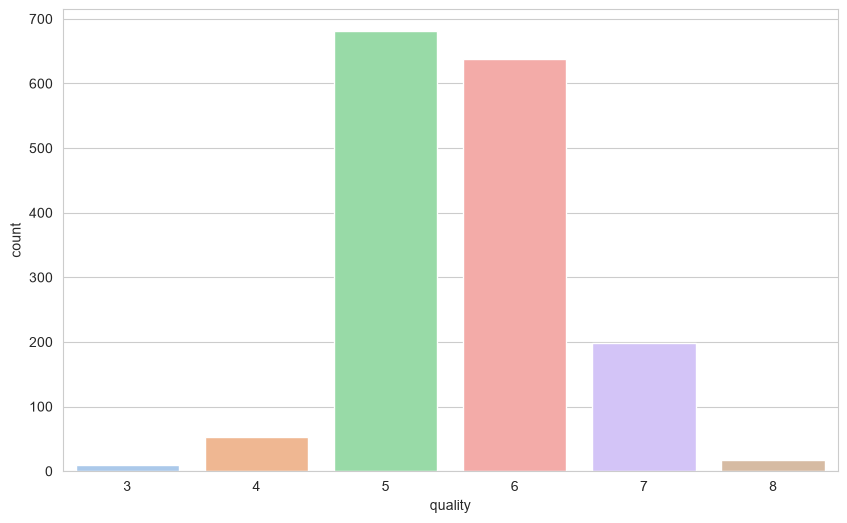

In [122]:
#visalization
sns.set_style(style='whitegrid')
print(wdf['quality'].value_counts())
fig = plt.figure(figsize=(10,6))
sns.countplot(data=wdf,x='quality',palette='pastel')

In [124]:
num_col=wdf.select_dtypes(include='number')
num_col.corr()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
fixed acidity,1.000000,-0.256131,0.671703,0.114777,0.093705,-0.153794,-0.113181,0.668047,-0.682978,0.183006,-0.061668,0.124052
volatile acidity,-0.256131,1.000000,-0.552496,0.001918,0.061298,-0.010504,0.076470,0.022026,0.234937,-0.260987,-0.202288,-0.390558
citric acid,0.671703,-0.552496,1.000000,0.143577,0.203823,-0.060978,0.035533,0.364947,-0.541904,0.312770,0.109903,0.226373
residual sugar,0.114777,0.001918,0.143577,1.000000,0.055610,0.187049,0.203028,0.355283,-0.085652,0.005527,0.042075,0.013732
chlorides,0.093705,0.061298,0.203823,0.055610,1.000000,0.005562,0.047400,0.200632,-0.265026,0.371260,-0.221141,-0.128907
free sulfur dioxide,-0.153794,-0.010504,-0.060978,0.187049,0.005562,1.000000,0.667666,-0.021946,0.070377,0.051658,-0.069408,-0.050656
total sulfur dioxide,-0.113181,0.076470,0.035533,0.203028,0.047400,0.667666,1.000000,0.071269,-0.066495,0.042947,-0.205654,-0.185100
density,0.668047,0.022026,0.364947,0.355283,0.200632,-0.021946,0.071269,1.000000,-0.341699,0.148506,-0.496180,-0.174919
pH,-0.682978,0.234937,-0.541904,-0.085652,-0.265026,0.070377,-0.066495,-0.341699,1.000000,-0.196648,0.205633,-0.057731
sulphates,0.183006,-0.260987,0.312770,0.005527,0.371260,0.051658,0.042947,0.148506,-0.196648,1.000000,0.093595,0.251397


<Axes: >

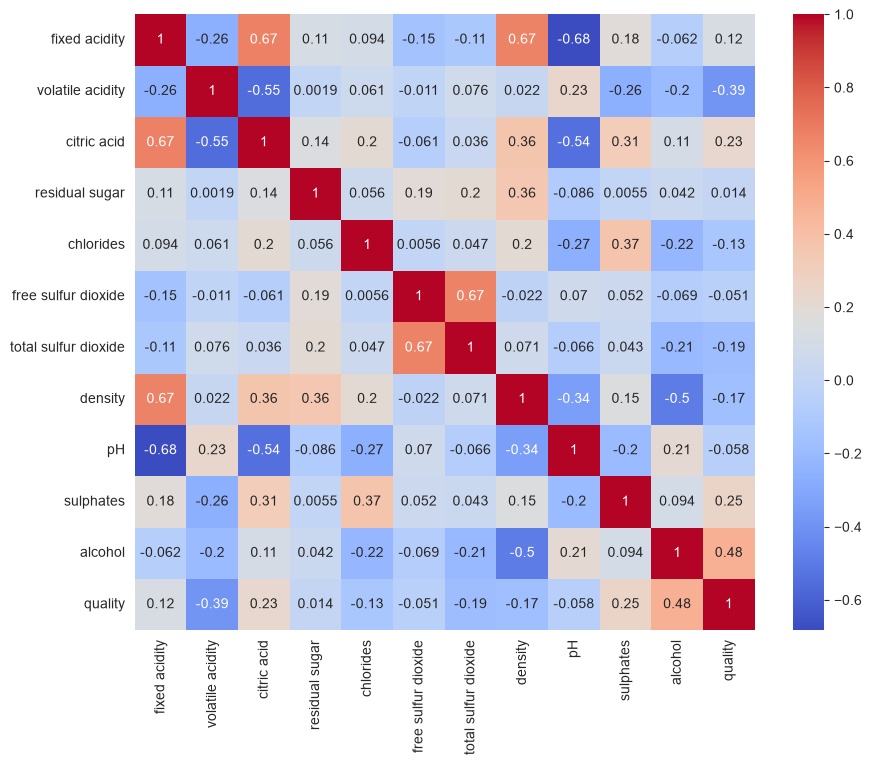

In [126]:
plt.figure(figsize=(10,8))
sns.heatmap(num_col.corr(),annot=True,cmap='coolwarm')

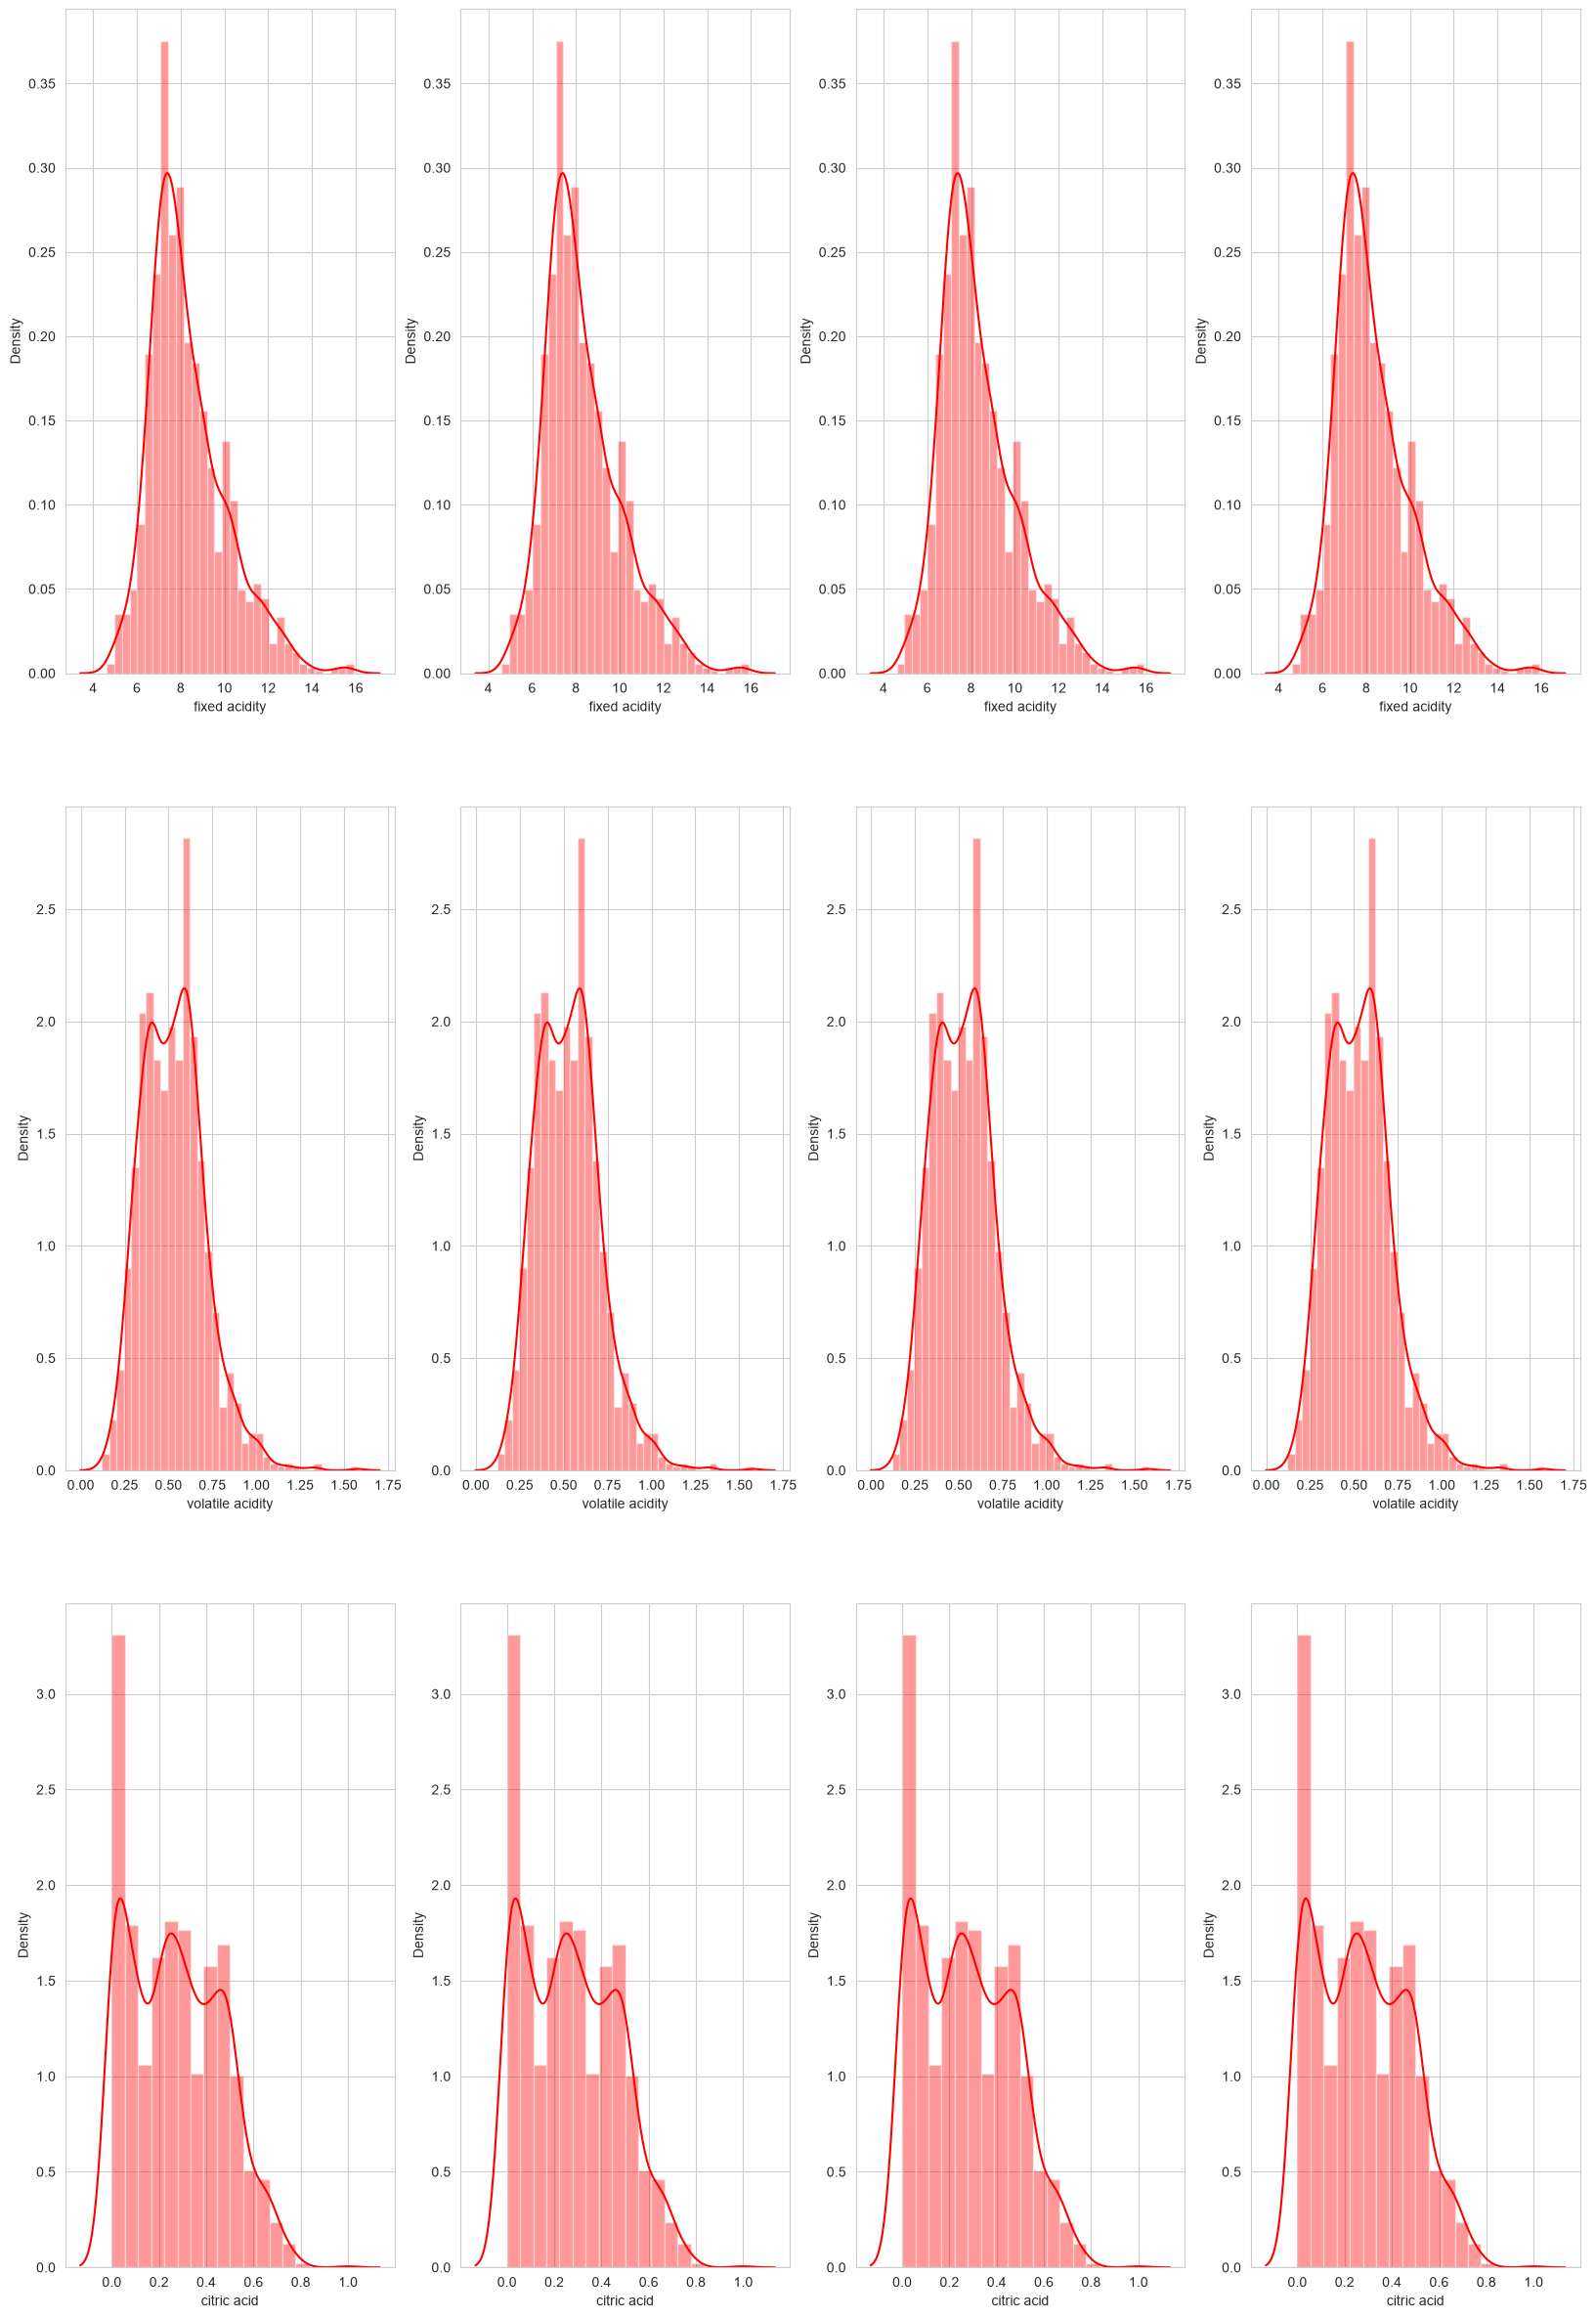

In [131]:
color=sns.color_palette('pastel')
fig,ax1=plt.subplots(3,4,figsize=(20,30))
k=0
columns=list(wdf.columns)
for i in range (3):
    for j in range(4):
        sns.distplot(wdf[columns[k]],ax=ax1[i][j],color='red')
    k=k+1

In [140]:
#log transformation 
def log_transformation(col):
    return np.log(col)

In [141]:
wdf['residual sugar']=wdf[['residual sugar']].apply(log_transformation,axis=1)
wdf['chlorides']=wdf[['chlorides']].apply(log_transformation,axis=1)
wdf['free sulfur dioxide']=wdf[['free sulfur dioxide']].apply(log_transformation,axis=1)
wdf['total sulfur dioxide']=wdf[['total sulfur dioxide']].apply(log_transformation,axis=1)
wdf['sulphates']=wdf[['sulphates']].apply(log_transformation,axis=1)

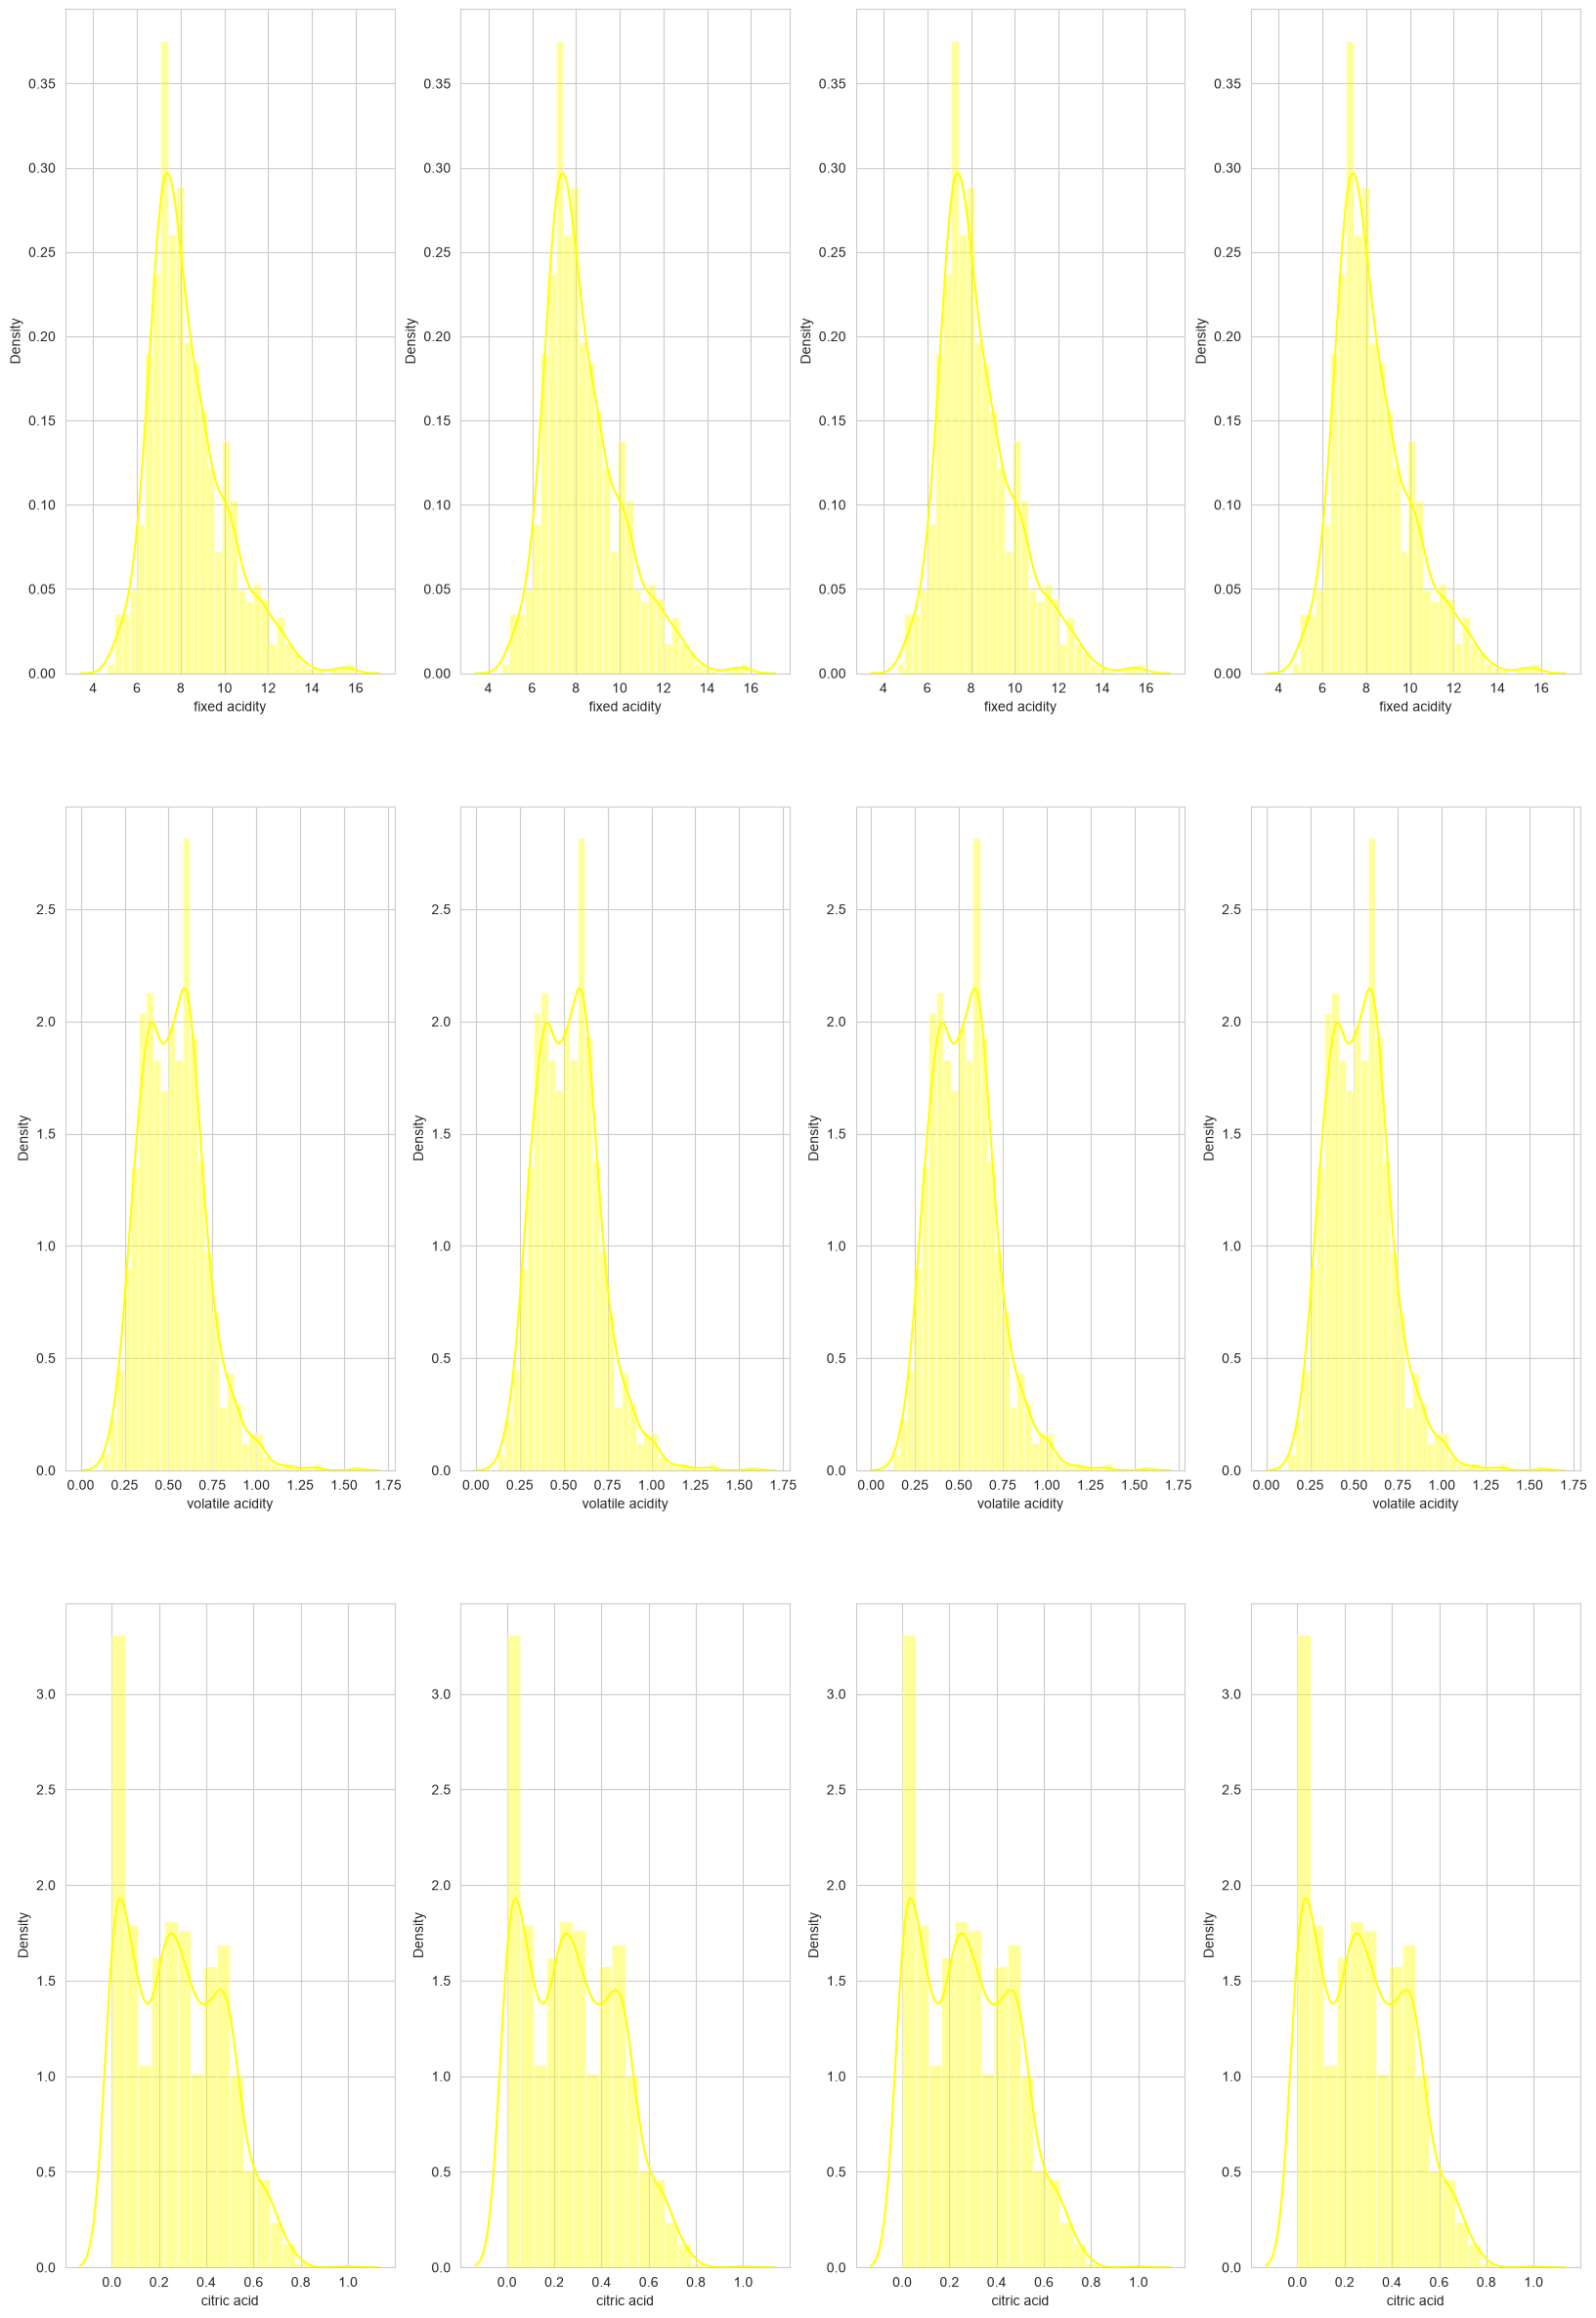

In [143]:
color=sns.color_palette('pastel')
fig,ax1=plt.subplots(3,4,figsize=(20,30))
k=0
columns=list(wdf.columns)
for i in range (3):
    for j in range(4):
        sns.distplot(wdf[columns[k]],ax=ax1[i][j],color='yellow')
    k=k+1

In [144]:
wdf.corr()['quality'].sort_values(ascending=False)

quality                 1.000000
alcohol                 0.476166
sulphates               0.308642
citric acid             0.226373
fixed acidity           0.124052
residual sugar          0.023533
free sulfur dioxide    -0.050087
pH                     -0.057731
total sulfur dioxide   -0.170143
density                -0.174919
chlorides              -0.176140
volatile acidity       -0.390558
Name: quality, dtype: float64

In [145]:
#datashet split
x=wdf.drop(columns=['quality'])#x-independent variable
Y=wdf['quality']# Y is dependent
Y.value_counts()

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

In [146]:
pip install imblearn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [148]:
from imblearn.over_sampling import SMOTE
oversample = SMOTE(k_neighbors=4)
x,Y = oversample.fit_resample(x.fillna(0),Y)

In [150]:
Y.value_counts()

quality
5    681
6    681
7    681
4    681
8    681
3    681
Name: count, dtype: int64

In [152]:
from sklearn.model_selection import  train_test_split,cross_val_score

In [153]:
def classify(model,x,Y):
    x_train,x_test,Y_train,Y_test= train_test_split(x,Y,test_size=0.2,
                                                   random_state=9)
    model.fit(x_train,Y_train)
    return model.score(x_test,Y_test)*100

In [155]:
#apply logistic regression
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
LR_acc= classify(model,x,Y)
LR_acc

52.68948655256723

In [157]:
#apply RFC
from sklearn.ensemble import RandomForestClassifier
model_rf = RandomForestClassifier()
rf_acc=classify(model_rf,x,Y)
rf_acc

87.89731051344744